In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys, platform
print("Python:", sys.version)
print("OS:", platform.platform())

import shutil, os
os.environ["HADOOP_HOME"] = "C:\\hadoop"
os.environ["PATH"] += ";C:\\hadoop\\bin"

print("HADOOP_HOME: ", os.environ.get("HADOOP_HOME"))

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T

Python: 3.12.7 | packaged by conda-forge | (main, Oct  4 2024, 15:47:54) [MSC v.1941 64 bit (AMD64)]
OS: Windows-11-10.0.26200-SP0
HADOOP_HOME:  C:\hadoop


In [150]:
spark = SparkSession.builder.appName("Tubes Project").getOrCreate()
spark

In [151]:
data_path = "../../data/raw/flipkart_product.csv"
df = spark.read.csv(data_path, header=True, inferSchema=True)

print("Total rows:", df.count())
df.limit(5).toPandas()

Total rows: 189874


,ProductName,Price,Rate,Review,Summary
0,Candes 12 L Room/Personal Air Cooler?�?�(White...,"�??3,999",5,Super!,Great cooler.. excellent air flow and for this...
1,Candes 12 L Room/Personal Air Cooler?�?�(White...,"�??3,999",5,Awesome,Best budget 2 fit cooler. Nice cooling
2,Candes 12 L Room/Personal Air Cooler?�?�(White...,"�??3,999",3,Fair,The quality is good but the power of air is de...
3,Candes 12 L Room/Personal Air Cooler?�?�(White...,"�??3,999",1,Useless product,Very bad product it's a only a fan
4,Candes 12 L Room/Personal Air Cooler?�?�(White...,"�??3,999",3,Fair,Ok ok product


In [152]:
df.printSchema()

root
 |-- ProductName: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- Rate: string (nullable = true)
 |-- Review: string (nullable = true)
 |-- Summary: string (nullable = true)



In [153]:
na_counts = df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns])
na_counts.show()


+-----------+-----+----+------+-------+
|ProductName|Price|Rate|Review|Summary|
+-----------+-----+----+------+-------+
|          0|    1|   1|     4|     14|
+-----------+-----+----+------+-------+



In [154]:
unique_counts = df.agg(*(F.countDistinct(F.col(c)).alias(c) for c in df.columns))
unique_counts.show()


+-----------+-----+----+------+-------+
|ProductName|Price|Rate|Review|Summary|
+-----------+-----+----+------+-------+
|        812|  563|  12|  1270|  98262|
+-----------+-----+----+------+-------+



## Preprocessing

In [155]:
# ============================================================================
# DATA CLEANING & PREPROCESSING
# ============================================================================
print("\n" + "="*80)
print("DATA CLEANING & PREPROCESSING")
print("="*80)

# 1. Clean Price column - remove currency symbols, commas, and convert to numeric
print("\n1. Cleaning Price column...")
print("-" * 80)

# Remove all non-numeric characters except decimal point
df = df.withColumn(
    "Price_cleaned",
    F.regexp_replace(F.col("Price"), "[^0-9.]", "")
).withColumn(
    "Price_numeric",
    F.when(F.col("Price_cleaned") == "", None)
     .otherwise(F.col("Price_cleaned").cast("double"))
)

# Check Price cleaning results
print("\nSample of Price cleaning (first 20 rows):")
df.select("Price", "Price_cleaned", "Price_numeric").show(20, truncate=False)

# Statistics on Price
print("\nPrice statistics:")
df.select(
    F.count(F.col("Price_numeric")).alias("valid_prices"),
    F.count(F.when(F.col("Price_numeric").isNull(), 1)).alias("null_prices"),
    F.min(F.col("Price_numeric")).alias("min_price"),
    F.max(F.col("Price_numeric")).alias("max_price"),
    F.avg(F.col("Price_numeric")).alias("avg_price")
).show()

# Check for invalid prices
invalid_prices = df.filter(F.col("Price_numeric").isNull() | (F.col("Price_numeric") <= 0))
print(f"\nInvalid prices (null or <= 0): {invalid_prices.count()}")
if invalid_prices.count() > 0 and invalid_prices.count() < 100:
    print("Sample invalid prices:")
    invalid_prices.select("Price", "Price_cleaned", "Price_numeric").show(10, truncate=False)



DATA CLEANING & PREPROCESSING

1. Cleaning Price column...
--------------------------------------------------------------------------------

Sample of Price cleaning (first 20 rows):
+--------+-------------+-------------+
|Price   |Price_cleaned|Price_numeric|
+--------+-------------+-------------+
|�??3,999|3999         |3999.0       |
|�??3,999|3999         |3999.0       |
|�??3,999|3999         |3999.0       |
|�??3,999|3999         |3999.0       |
|�??3,999|3999         |3999.0       |
|�??3,999|3999         |3999.0       |
|�??3,999|3999         |3999.0       |
|�??3,999|3999         |3999.0       |
|�??3,999|3999         |3999.0       |
|�??3,999|3999         |3999.0       |
|�??8,999|8999         |8999.0       |
|�??8,999|8999         |8999.0       |
|�??8,999|8999         |8999.0       |
|�??8,999|8999         |8999.0       |
|�??8,999|8999         |8999.0       |
|�??8,999|8999         |8999.0       |
|�??8,999|8999         |8999.0       |
|�??8,999|8999         |8999.0      

In [156]:
# 2. Convert Rate to numeric (should be 1-5)
print("\n2. Converting Rate to numeric...")
# First, check what values are in Rate column that might cause issues
print("\nChecking unique Rate values (first 20):")
df.select("Rate").distinct().show(20, truncate=False)


df = df.withColumn(
    "Rate_cleaned",
    F.regexp_replace(F.col("Rate"), "[^0-9]", "")  # Remove all non-numeric characters
).withColumn(
    "Rate_numeric",
    F.when(F.col("Rate").isNull(), None)
     .when(F.col("Rate") == "", None)
     .when(F.col("Rate_cleaned") == "", None)  # Empty after cleaning
     .when(
         (F.col("Rate_cleaned").rlike("^[1-5]$")), 
         F.col("Rate_cleaned").cast("int")
     )
     .otherwise(None)  # Set to None if not valid
)





2. Converting Rate to numeric...

Checking unique Rate values (first 20):
+-----------------------------------------------------------+
|Rate                                                       |
+-----------------------------------------------------------+
|3                                                          |
|5                                                          |
|1                                                          |
|4                                                          |
|2                                                          |
| Black                                                     |
|Pigeon Favourite Electric Kettle?�?�(1.5 L, Silver, Black) |
|₹3,295                                                     |
|Nova Plus Amaze NI 10 1100 W Dry Iron?�?�(Grey & Turquoise)|
|₹2,969                                                     |
|Bajaj DX 2 L/W Dry Iron                                    |
|s                                                       

In [157]:
# Check Rate conversion
print("\nSample of Rate conversion (first 20 rows):")
df.select("Rate", "Rate_cleaned", "Rate_numeric").show(20, truncate=False)

# Check for invalid rates before showing distribution
invalid_rates_count = df.filter(F.col("Rate_numeric").isNull()).count()
print(f"\nInvalid rates (null): {invalid_rates_count}")

if invalid_rates_count > 0 and invalid_rates_count < 100:
    print("Sample invalid rates:")
    df.filter(F.col("Rate_numeric").isNull()).select("Rate", "Rate_cleaned", "Rate_numeric").show(10, truncate=False)




Sample of Rate conversion (first 20 rows):
+----+------------+------------+
|Rate|Rate_cleaned|Rate_numeric|
+----+------------+------------+
|5   |5           |5           |
|5   |5           |5           |
|3   |3           |3           |
|1   |1           |1           |
|3   |3           |3           |
|5   |5           |5           |
|5   |5           |5           |
|3   |3           |3           |
|1   |1           |1           |
|4   |4           |4           |
|5   |5           |5           |
|5   |5           |5           |
|5   |5           |5           |
|5   |5           |5           |
|5   |5           |5           |
|5   |5           |5           |
|5   |5           |5           |
|5   |5           |5           |
|5   |5           |5           |
|5   |5           |5           |
+----+------------+------------+
only showing top 20 rows

Invalid rates (null): 439


In [158]:
# Rate distribution (only valid rates)
print("\nRate distribution (valid rates only):")
df.filter(F.col("Rate_numeric").isNotNull()).groupBy("Rate_numeric").count().orderBy("Rate_numeric").show()

# Check for rates outside 1-5 range
invalid_range = df.filter(
    F.col("Rate_numeric").isNotNull() & 
    ((F.col("Rate_numeric") < 1) | (F.col("Rate_numeric") > 5))
)
print(f"\nRates outside 1-5 range: {invalid_range.count()}")
if invalid_range.count() > 0:
    invalid_range.select("Rate", "Rate_cleaned", "Rate_numeric").show(10, truncate=False)


Rate distribution (valid rates only):
+------------+------+
|Rate_numeric| count|
+------------+------+
|           1| 19552|
|           2|  6207|
|           3| 15643|
|           4| 39557|
|           5|108476|
+------------+------+


Rates outside 1-5 range: 0


In [159]:
# 3. Handle Missing Values
print("\n3. Handling Missing Values...")
print("-" * 80)

# Check missing values after cleaning
print("\nMissing values after cleaning:")
missing_after = df.select([
    F.count(F.when(F.col("ProductName").isNull(), 1)).alias("ProductName_null"),
    F.count(F.when(F.col("Price_numeric").isNull(), 1)).alias("Price_null"),
    F.count(F.when(F.col("Rate_numeric").isNull(), 1)).alias("Rate_null"),
    F.count(F.when(F.col("Review").isNull(), 1)).alias("Review_null"),
    F.count(F.when(F.col("Summary").isNull(), 1)).alias("Summary_null")
])
missing_after.show()

# Remove rows with critical missing values (Price or Rate)
print("\nRemoving rows with missing Price or Rate...")
df_cleaned = df.filter(
    F.col("ProductName").isNotNull() & 
    F.col("Price_numeric").isNotNull() & 
    F.col("Rate_numeric").isNotNull() &
    F.col("Review").isNotNull() &
    F.col("Summary").isNotNull()
)

print(f"Original rows: {df.count()}")
print(f"Rows after removing missing Price/Rate: {df_cleaned.count()}")
print(f"Rows removed: {df.count() - df_cleaned.count()}")

# Update df
df = df_cleaned



3. Handling Missing Values...
--------------------------------------------------------------------------------

Missing values after cleaning:
+----------------+----------+---------+-----------+------------+
|ProductName_null|Price_null|Rate_null|Review_null|Summary_null|
+----------------+----------+---------+-----------+------------+
|               0|       436|      439|          4|          14|
+----------------+----------+---------+-----------+------------+


Removing rows with missing Price or Rate...
Original rows: 189874
Rows after removing missing Price/Rate: 189419
Rows removed: 455


In [160]:
# 4. Create cleaned dataset with proper column names
print("\n4. Creating cleaned dataset...")
print("-" * 80)

# Select and rename columns for final cleaned dataset
df_clean = df.select(
    F.col("ProductName").alias("product_name"),
    F.col("Price_numeric").alias("price"),
    F.col("Rate_numeric").alias("rate"),
    F.col("Review").alias("review"),
    F.col("Summary").alias("summary")
)

print("\nCleaned dataset schema:")
df_clean.printSchema()

print("\nSample of cleaned data (first 10 rows):")
df_clean.show(10, truncate=False)

print(f"\nFinal dataset shape: {df_clean.count()} rows")



4. Creating cleaned dataset...
--------------------------------------------------------------------------------

Cleaned dataset schema:
root
 |-- product_name: string (nullable = true)
 |-- price: double (nullable = true)
 |-- rate: integer (nullable = true)
 |-- review: string (nullable = true)
 |-- summary: string (nullable = true)


Sample of cleaned data (first 10 rows):
+-----------------------------------------------------------------------------------------------------------------------+------+----+------------------+----------------------------------------------------------------------------------------------------------+
|product_name                                                                                                           |price |rate|review            |summary                                                                                                   |
+---------------------------------------------------------------------------------------------------

In [161]:
# 5. Gabungkan review dan summary, lalu bersihkan teks gabungan
print("\n5. Combine review and summary to a single column...")
print("-" * 80)

# Pastikan kolom ada dan bertipe string
df_clean = df_clean.withColumn("review", F.col("review").cast("string")) \
       .withColumn("summary", F.col("summary").cast("string"))

# Gabungkan review dan summary menjadi satu kolom sementara (pisahkan dengan "titik spasi" jika keduanya ada
# Gunakan coalesce untuk mengganti null dengan empty string agar concat tidak menghasilkan null.
df_clean = df_clean.withColumn(
    "review_summary_raw",
    F.concat_ws(". ", F.coalesce(F.col("review"), F.lit("")), F.coalesce(F.col("summary"), F.lit("")))
)

# Bersihkan teks menggunakan fungsi Spark SQL (lower, hapus HTML, URL, non-alnum, collapse multiple spaces)
df_clean = df_clean.withColumn("review_summary",
    F.trim(
        F.regexp_replace(
            F.regexp_replace(
                F.regexp_replace(F.lower(F.col("review_summary_raw")), r"<.*?>", " "),          # remove HTML tags
                r"http\S+|www\S+|https\S+", " "),                                               # remove URLs
                r"[^a-z0-9\s]", " ")                                                            # keep all number & space
    )
)

# Collapse multiple spaces menjadi satu dan hilangkan leading/trailing spaces
df_clean = df_clean.withColumn("review_summary", F.regexp_replace(F.col("review_summary"), r"\s+", " "))

# Buang baris yang kosong setelah pembersihan (harusnya tidak ada, tapi untuk jaga-jaga)
df_clean = df_clean.filter(F.col("review_summary").isNotNull() & (F.col("review_summary") != ""))

# Hapus kolom sementara
df_clean = df_clean.drop("review_summary_raw")

df_clean.select("review", "summary", "review_summary").show(10, truncate=200)
df_clean.select(
    F.count(F.when(F.col("review_summary").isNull(), 1)).alias("null_review_summary"),
    F.count(F.when(F.col("review_summary") == "", 1)).alias("empty_review_summary")
).show()



5. Combine review and summary to a single column...
--------------------------------------------------------------------------------
+------------------+----------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------+
|            review|                                                                                                   summary|                                                                                        review_summary|
+------------------+----------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------+
|            Super!|Great cooler.. excellent air flow and for this price. It's so amazing and unbelievable.Just love it ��?�?�|super great cooler excellent air flow and for 

In [163]:
# 6. Map rate manjadi label_text
print("\n6. Label sentiment based on rate...")
print("-" * 80)

df_clean = df_clean.withColumn("rate_num", F.col("rate").cast("double"))

df_clean = df_clean.withColumn(
    "label_text",
    F.when(F.col("rate_num") <= 2.0, F.lit("negative"))
     .when(F.col("rate_num") == 3.0, F.lit("neutral"))
     .when(F.col("rate_num") >= 4.0, F.lit("positive"))
     .otherwise(F.lit(None))
)

df_clean = df_clean.filter(F.col("label_text").isNotNull())
df_clean.select("review_summary", "rate_num", "label_text").show(10, truncate=200)

# Simpan hasil preprocessing ke format Parquet (lebih aman untuk tipe data Spark)
output_path = "../../data/processed/tubes/processed_flipkart.parquet"

# Hapus folder lama jika ada
if os.path.exists(output_path):
    shutil.rmtree(output_path)

df_clean.write.mode("overwrite").parquet(output_path)

print("Data berhasil disimpan ke:", output_path)


6. Label sentiment based on rate...
--------------------------------------------------------------------------------
+------------------------------------------------------------------------------------------------------+--------+----------+
|                                                                                        review_summary|rate_num|label_text|
+------------------------------------------------------------------------------------------------------+--------+----------+
|super great cooler excellent air flow and for this price it s so amazing and unbelievable just love it|     5.0|  positive|
|                                                         awesome best budget 2 fit cooler nice cooling|     5.0|  positive|
|                                               fair the quality is good but the power of air is decent|     3.0|   neutral|
|                                                    useless product very bad product it s a only a fan|     1.0|  negative|
|      

In [164]:
# # 7. Data Exploration - Statistics
# print("\n7. Data Exploration - Statistics")
# print("="*80)

# # Basic statistics
# print("\nBasic Statistics:")
# print("-" * 80)
# df_clean.describe(["price", "rate"]).show()

# # Price distribution by Rate
# print("\nPrice statistics by Rate:")
# print("-" * 80)
# df_clean.groupBy("rate").agg(
#     F.count("*").alias("count"),
#     F.avg("price").alias("avg_price"),
#     F.min("price").alias("min_price"),
#     F.max("price").alias("max_price"),
#     F.stddev("price").alias("std_price")
# ).orderBy("rate").show()

# # Top products by count
# print("\nTop 10 Products by Review Count:")
# print("-" * 80)
# df_clean.groupBy("product_name").count().orderBy(F.desc("count")).show(10, truncate=False)


## EDA

In [165]:
# ============================================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# Convert to Pandas for easier visualization (using full dataset)
print("\nConverting Spark DataFrame to Pandas for visualization...")
df_pandas = df_clean.toPandas()

print(f"\nDataset shape: {df_pandas.shape}")
print(f"Memory usage: {df_pandas.memory_usage(deep=True).sum() / 1024**2:.2f} MB")



EXPLORATORY DATA ANALYSIS (EDA)

Converting Spark DataFrame to Pandas for visualization...

Dataset shape: (189419, 8)
Memory usage: 90.83 MB


In [166]:
# 2. Statistical Summary
print("\n2. STATISTICAL SUMMARY")
print("-" * 80)

print("\nDescriptive Statistics for Numerical Columns:")
print(df_pandas[['price', 'rate']].describe())

print("\nAdditional Statistics:")
print(f"Price - Median: {df_pandas['price'].median():.2f}")
print(f"Price - Skewness: {df_pandas['price'].skew():.2f}")
print(f"Price - Kurtosis: {df_pandas['price'].kurtosis():.2f}")
print(f"Rate - Median: {df_pandas['rate'].median():.2f}")
print(f"Rate - Mode: {df_pandas['rate'].mode().values[0]}")



2. STATISTICAL SUMMARY
--------------------------------------------------------------------------------

Descriptive Statistics for Numerical Columns:
               price           rate
count  189419.000000  189419.000000
mean     4352.192890       4.114856
std     10213.816133       1.304631
min         2.000000       1.000000
25%       339.000000       4.000000
50%       699.000000       5.000000
75%      3399.000000       5.000000
max     86990.000000       5.000000

Additional Statistics:
Price - Median: 699.00
Price - Skewness: 4.67
Price - Kurtosis: 26.29
Rate - Median: 5.00
Rate - Mode: 5



3. PRICE DISTRIBUTION ANALYSIS
--------------------------------------------------------------------------------


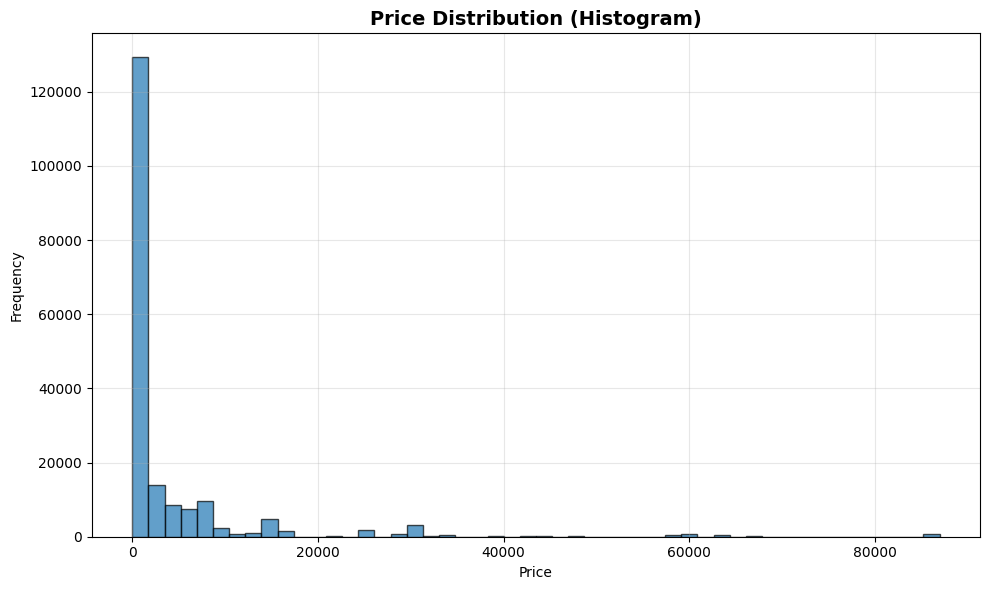


Price Percentiles:
10th percentile: 225.00
25th percentile: 339.00
50th percentile: 699.00
75th percentile: 3399.00
90th percentile: 9999.00
95th percentile: 24490.00
99th percentile: 59990.00


In [167]:
# 3. Distribution Analysis - Price
print("\n3. PRICE DISTRIBUTION ANALYSIS")
print("-" * 80)

plt.figure(figsize=(10,6))
plt.hist(df_pandas['price'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Price Distribution (Histogram)', fontsize=14, fontweight='bold')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Price statistics by percentiles
print("\nPrice Percentiles:")
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(df_pandas['price'], p):.2f}")



4. RATE DISTRIBUTION ANALYSIS
--------------------------------------------------------------------------------


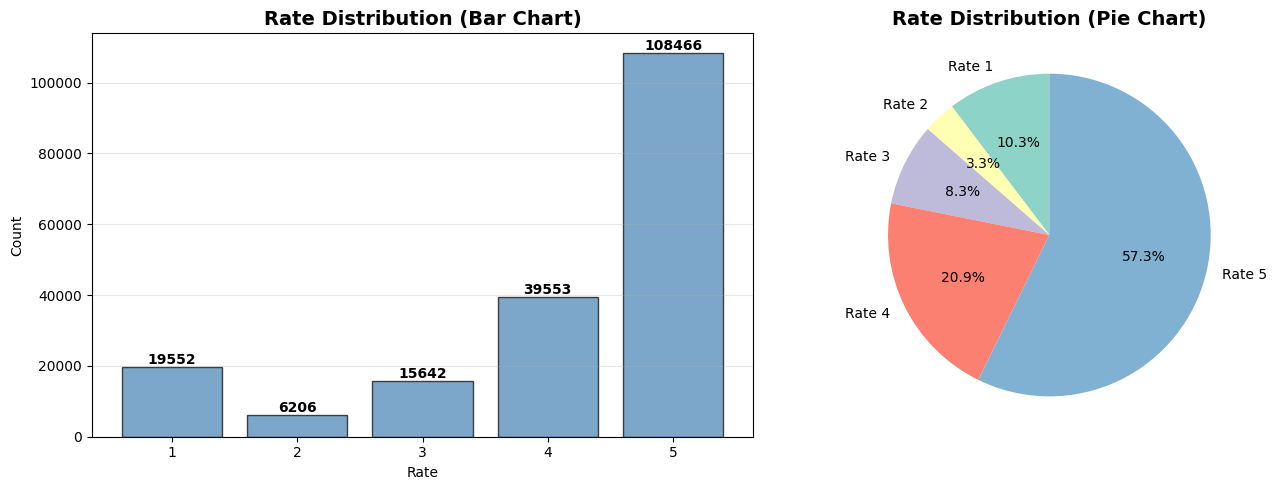


Rate Distribution:
rate
1     19552
2      6206
3     15642
4     39553
5    108466
Name: count, dtype: int64

Percentage distribution:
Rate 1: 19552 (10.32%)
Rate 2: 6206 (3.28%)
Rate 3: 15642 (8.26%)
Rate 4: 39553 (20.88%)
Rate 5: 108466 (57.26%)


In [168]:
# 4. Distribution Analysis - Rate
print("\n4. RATE DISTRIBUTION ANALYSIS")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot for rate distribution
rate_counts = df_pandas['rate'].value_counts().sort_index()
axes[0].bar(rate_counts.index, rate_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Rate Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rate')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(1, 6))
axes[0].grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, v in enumerate(rate_counts.values):
    axes[0].text(rate_counts.index[i], v, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(rate_counts.values, labels=[f'Rate {i}' for i in rate_counts.index], 
            autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
axes[1].set_title('Rate Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nRate Distribution:")
print(rate_counts)
print(f"\nPercentage distribution:")
for rate, count in rate_counts.items():
    print(f"Rate {rate}: {count} ({count/len(df_pandas)*100:.2f}%)")



6. OUTLIER DETECTION
--------------------------------------------------------------------------------
IQR Method:
Q1: 339.00, Q3: 3399.00, IQR: 3060.00
Lower bound: -4251.00, Upper bound: 7989.00
Number of outliers: 25375 (13.40%)

Z-score Method (|z| > 3):
Number of outliers: 3791 (2.00%)


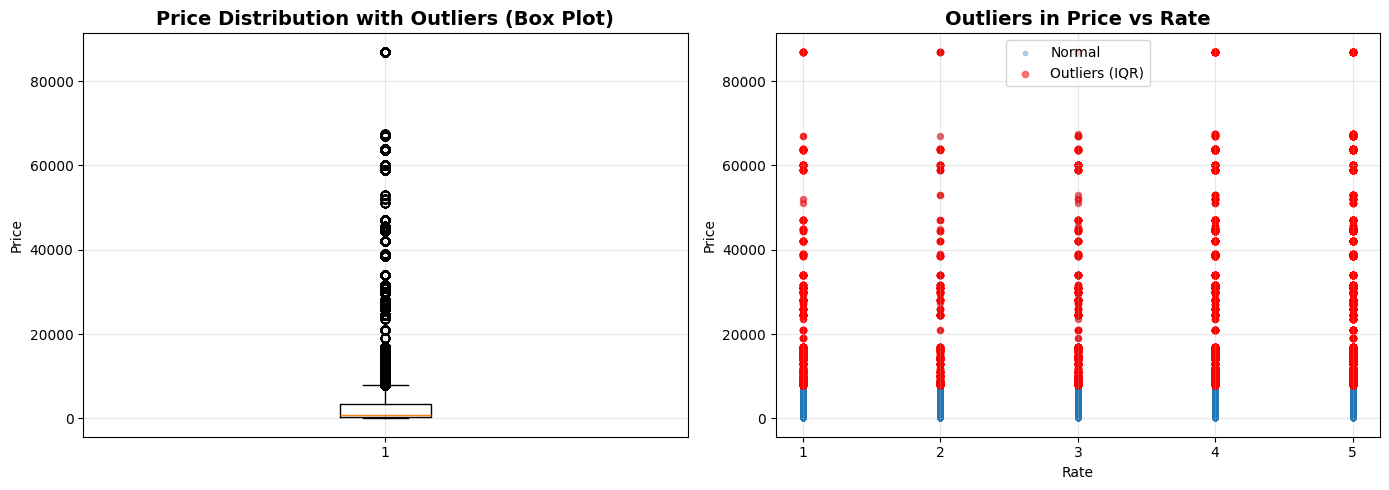


Top 10 Highest Prices:
                                            product_name    price  rate
96609  APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...  86990.0     4
96610  APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...  86990.0     5
96611  APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...  86990.0     5
96612  APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...  86990.0     5
96613  APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...  86990.0     5
96614  APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...  86990.0     5
96615  APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...  86990.0     5
96616  APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...  86990.0     5
96617  APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...  86990.0     5
96618  APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...  86990.0     4


In [169]:
# 6. Outlier Detection
print("\n6. OUTLIER DETECTION")
print("-" * 80)

# Using IQR method
Q1 = df_pandas['price'].quantile(0.25)
Q3 = df_pandas['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_pandas[(df_pandas['price'] < lower_bound) | (df_pandas['price'] > upper_bound)]
print(f"IQR Method:")
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(df_pandas)*100:.2f}%)")

# Using Z-score method
from scipy import stats
z_scores = np.abs(stats.zscore(df_pandas['price']))
outliers_zscore = df_pandas[z_scores > 3]
print(f"\nZ-score Method (|z| > 3):")
print(f"Number of outliers: {len(outliers_zscore)} ({len(outliers_zscore)/len(df_pandas)*100:.2f}%)")

# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot with outliers highlighted
axes[0].boxplot(df_pandas['price'], vert=True)
axes[0].set_title('Price Distribution with Outliers (Box Plot)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price')
axes[0].grid(True, alpha=0.3)

# Scatter plot highlighting outliers
axes[1].scatter(df_pandas['rate'], df_pandas['price'], alpha=0.3, s=10, label='Normal')
axes[1].scatter(outliers['rate'], outliers['price'], alpha=0.5, s=20, color='red', label='Outliers (IQR)')
axes[1].set_title('Outliers in Price vs Rate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rate')
axes[1].set_ylabel('Price')
axes[1].set_xticks(range(1, 6))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 10 Highest Prices:")
print(df_pandas.nlargest(10, 'price')[['product_name', 'price', 'rate']])



7. PRODUCT ANALYSIS
--------------------------------------------------------------------------------
Total unique products: 808

Top 20 Products by Review Count:
product_name
MILTON Thermosteel Flip Lid 500 ml Flask  (Pack of 1, Silver, Steel)                                                            9278
cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinner Set, 18 Pieces Dinner Set  (White, Microwave Safe)           8870
Home Sizzler 153 cm (5.02 ft) Polyester Room Darkening Window Curtain (Pack Of 2)  (Floral, Brown)                              4350
CMerchants Multi Organiser BLue-4 Book Shelf Metal Open Book Shelf  (Finish Color - BLUE, DIY(Do-It-Yourself))                  2399
Kadio Analog 20 cm X 20 cm Wall Clock  (Beige, With Glass, Standard)                                                            2380
Cosito 144 TC Cotton Double Floral Flat Bedsheet  (Pack of 1, Red, White)                                                       2322
Mi 5A 80 cm (32 inch) HD R

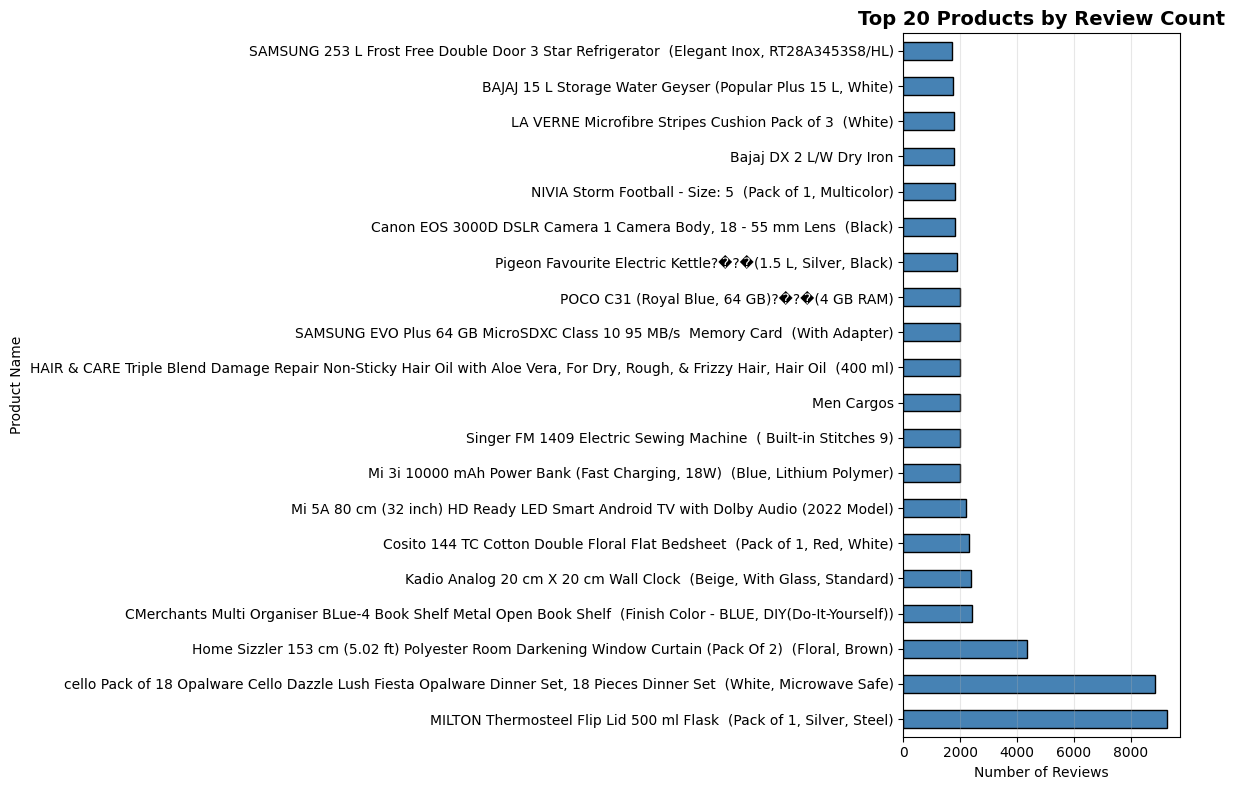


Top 20 Products - Price and Rate Statistics:
                                                    avg_price  min_price  \
product_name                                                               
MILTON Thermosteel Flip Lid 500 ml Flask  (Pack...     648.00      648.0   
cello Pack of 18 Opalware Cello Dazzle Lush Fie...    1299.00     1299.0   
Home Sizzler 153 cm (5.02 ft) Polyester Room Da...     299.00      299.0   
CMerchants Multi Organiser BLue-4 Book Shelf Me...     625.00      625.0   
Kadio Analog 20 cm X 20 cm Wall Clock  (Beige, ...     225.00      225.0   
Cosito 144 TC Cotton Double Floral Flat Bedshee...     339.00      339.0   
Mi 5A 80 cm (32 inch) HD Ready LED Smart Androi...   13999.00    13999.0   
Mi 3i 10000 mAh Power Bank (Fast Charging, 18W)...    1149.00     1149.0   
Singer FM 1409 Electric Sewing Machine  ( Built...    8499.00     8499.0   
Men Cargos                                             423.40      367.0   
HAIR & CARE Triple Blend Damage Repair Non

In [170]:
# 7. Product Analysis
print("\n7. PRODUCT ANALYSIS")
print("-" * 80)

# Number of unique products
unique_products = df_pandas['product_name'].nunique()
print(f"Total unique products: {unique_products}")

# Products with most reviews
top_products = df_pandas['product_name'].value_counts().head(20)
print("\nTop 20 Products by Review Count:")
print(top_products)

# Visualize top products
fig, axes = plt.subplots(1, 1, figsize=(12, 8))
top_products.plot(kind='barh', ax=axes, color='steelblue', edgecolor='black')
axes.set_title('Top 20 Products by Review Count', fontsize=14, fontweight='bold')
axes.set_xlabel('Number of Reviews')
axes.set_ylabel('Product Name')
axes.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Average price and rate by product
product_stats = df_pandas.groupby('product_name').agg({
    'price': ['mean', 'min', 'max', 'count'],
    'rate': ['mean', 'count']
}).round(2)
product_stats.columns = ['avg_price', 'min_price', 'max_price', 'review_count', 'avg_rate', 'rate_count']
product_stats = product_stats.sort_values('review_count', ascending=False).head(20)

print("\nTop 20 Products - Price and Rate Statistics:")
print(product_stats)



8. TEXT ANALYSIS - REVIEW AND SUMMARY
--------------------------------------------------------------------------------

Review Length Statistics:
count    189419.000000
mean         11.523928
std           5.653355
min           2.000000
25%           9.000000
50%          10.000000
75%          16.000000
max         140.000000
Name: review_length, dtype: float64

Summary Length Statistics:
count    189419.000000
mean         42.890127
std          71.495209
min           1.000000
25%           9.000000
50%          17.000000
75%          43.000000
max         526.000000
Name: summary_length, dtype: float64


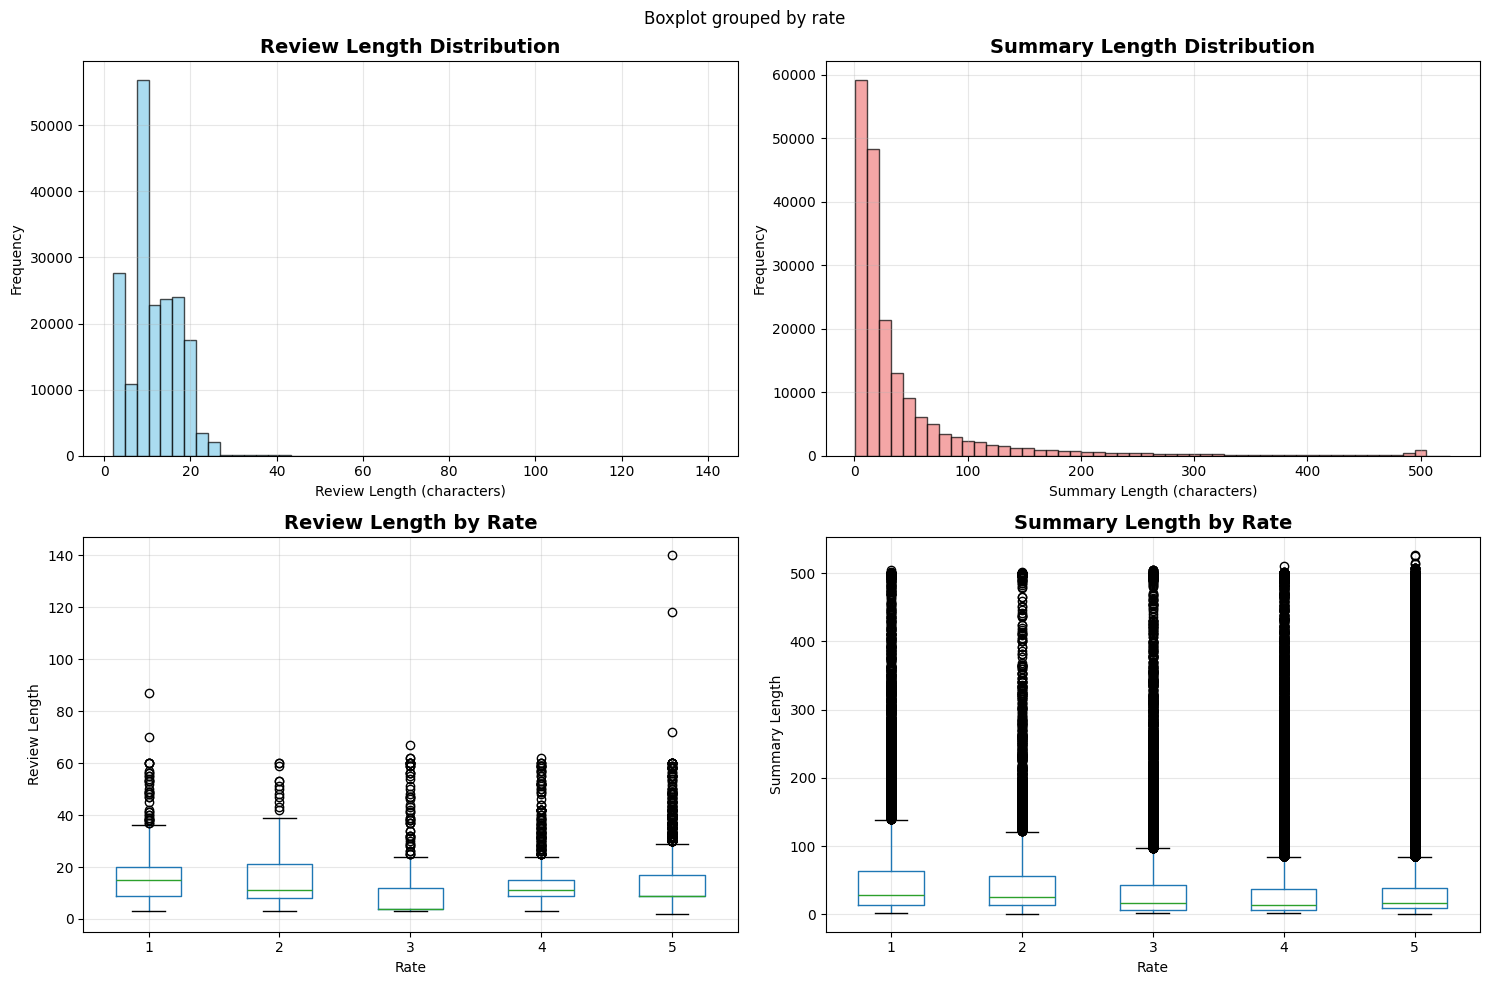


Average Review Length by Rate:
rate
1    14.047003
2    13.551563
3     7.301688
4    11.475438
5    11.579684
Name: review_length, dtype: float64

Average Summary Length by Rate:
rate
1    56.976678
2    52.921689
3    42.899182
4    40.855030
5    40.517738
Name: summary_length, dtype: float64


In [171]:
# 8. Text Analysis - Review and Summary
print("\n8. TEXT ANALYSIS - REVIEW AND SUMMARY")
print("-" * 80)

# Review length analysis
df_pandas['review_length'] = df_pandas['review'].astype(str).apply(len)
df_pandas['summary_length'] = df_pandas['summary'].astype(str).apply(len)

print("\nReview Length Statistics:")
print(df_pandas['review_length'].describe())

print("\nSummary Length Statistics:")
print(df_pandas['summary_length'].describe())

# Visualize text lengths
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Review length distribution
axes[0, 0].hist(df_pandas['review_length'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_title('Review Length Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Review Length (characters)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Summary length distribution
axes[0, 1].hist(df_pandas['summary_length'], bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
axes[0, 1].set_title('Summary Length Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Summary Length (characters)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Review length by rate
df_pandas.boxplot(column='review_length', by='rate', ax=axes[1, 0])
axes[1, 0].set_title('Review Length by Rate', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Rate')
axes[1, 0].set_ylabel('Review Length')
axes[1, 0].grid(True, alpha=0.3)

# Summary length by rate
df_pandas.boxplot(column='summary_length', by='rate', ax=axes[1, 1])
axes[1, 1].set_title('Summary Length by Rate', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Rate')
axes[1, 1].set_ylabel('Summary Length')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Relationship between text length and rate
print("\nAverage Review Length by Rate:")
print(df_pandas.groupby('rate')['review_length'].mean())

print("\nAverage Summary Length by Rate:")
print(df_pandas.groupby('rate')['summary_length'].mean())



9. SENTIMENT LABEL DISTRIBUTION ANALYSIS
--------------------------------------------------------------------------------


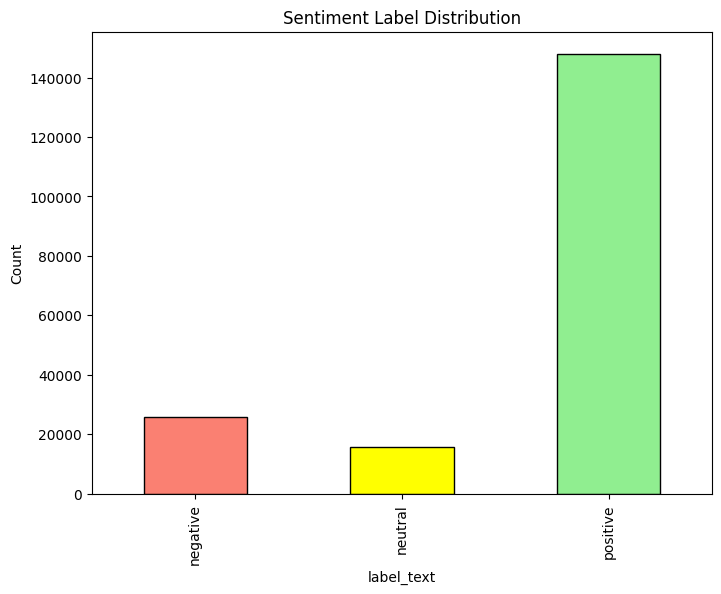

label_text
negative     25758
neutral      15642
positive    148019
Name: rate, dtype: int64

In [172]:
# 9. Distribution Analysis - Sentiment label
print("\n9. SENTIMENT LABEL DISTRIBUTION ANALYSIS")
print("-" * 80)

colors = ["salmon", "yellow", "lightgreen"]

label_counts = df_pandas.groupby("label_text")['rate'].count()
label_counts.plot(kind="bar", legend=False, color=colors, edgecolor='black', figsize=(8,6))
plt.title("Sentiment Label Distribution")
plt.ylabel("Count")
plt.show()

df_pandas.groupby("label_text")['rate'].count()


10. CORRELATION ANALYSIS
--------------------------------------------------------------------------------

Correlation Matrix:
                   price      rate  review_length  summary_length
price           1.000000  0.070701       0.077031        0.232405
rate            0.070701  1.000000      -0.072344       -0.068386
review_length   0.077031 -0.072344       1.000000        0.115781
summary_length  0.232405 -0.068386       0.115781        1.000000


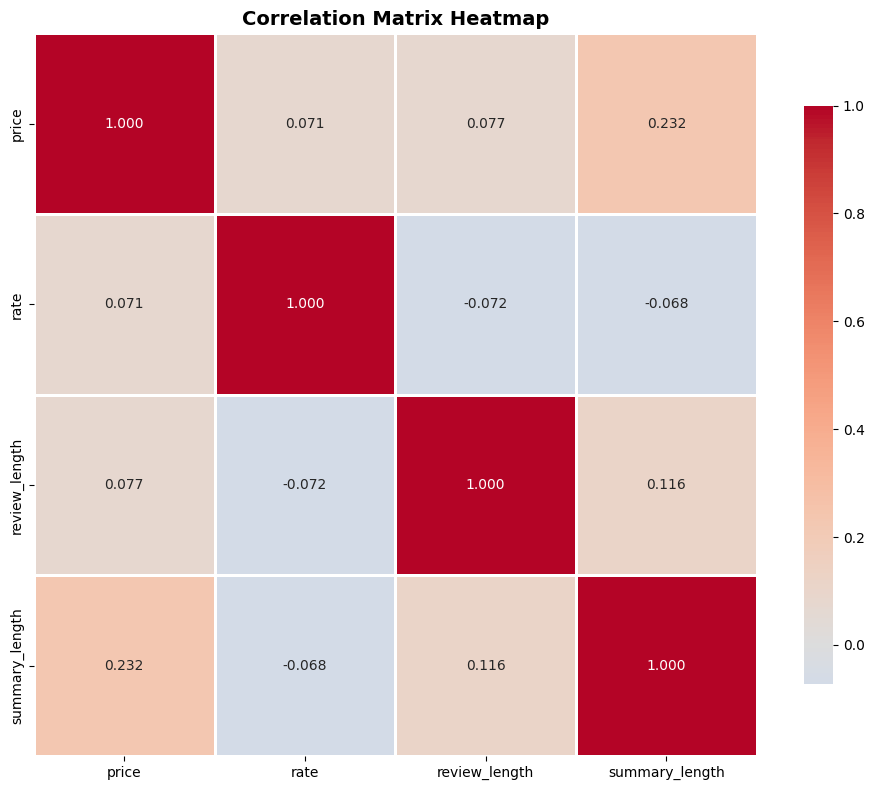


Correlation between Price and Rate: 0.0707


In [173]:
# 10. Correlation Analysis
print("\n10. CORRELATION ANALYSIS")
print("-" * 80)

# Calculate correlation
correlation_matrix = df_pandas[['price', 'rate', 'review_length', 'summary_length']].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Visualize correlation
fig, axes = plt.subplots(1, 1, figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes)
axes.set_title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation between price and rate
corr_price_rate = df_pandas['price'].corr(df_pandas['rate'])
print(f"\nCorrelation between Price and Rate: {corr_price_rate:.4f}")



11. PRICE RANGE ANALYSIS
--------------------------------------------------------------------------------

Distribution by Price Category:
price_category
Very Low (<1K)      102286
Low (1K-5K)          48299
Medium (5K-10K)      20558
Very High (>20K)     10301
High (10K-20K)        7975
Name: count, dtype: int64

Percentage:
Very Low (<1K): 54.00%
Low (1K-5K): 25.50%
Medium (5K-10K): 10.85%
Very High (>20K): 5.44%
High (10K-20K): 4.21%


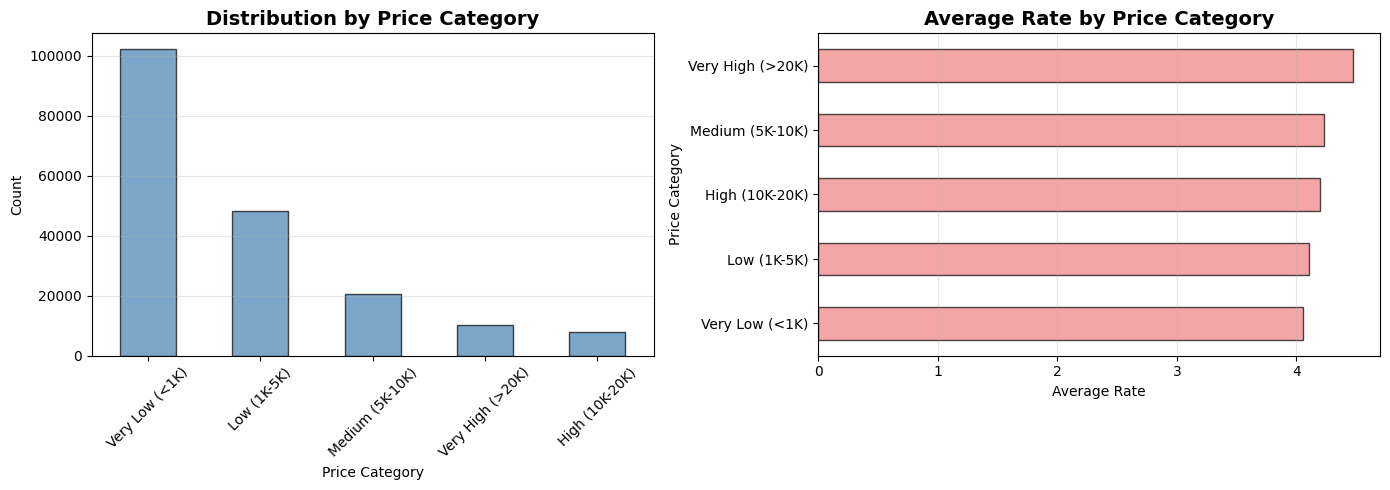


Average Rate by Price Category:
price_category
Very Low (<1K)      4.052050
Low (1K-5K)         4.109029
High (10K-20K)      4.197241
Medium (5K-10K)     4.228573
Very High (>20K)    4.475100
Name: rate, dtype: float64


In [174]:
# 11. Price Range Analysis
print("\n11. PRICE RANGE ANALYSIS")
print("-" * 80)

# Create price categories
def categorize_price(price):
    if price < 1000:
        return 'Very Low (<1K)'
    elif price < 5000:
        return 'Low (1K-5K)'
    elif price < 10000:
        return 'Medium (5K-10K)'
    elif price < 20000:
        return 'High (10K-20K)'
    else:
        return 'Very High (>20K)'

df_pandas['price_category'] = df_pandas['price'].apply(categorize_price)

# Distribution by price category
price_cat_dist = df_pandas['price_category'].value_counts()
print("\nDistribution by Price Category:")
print(price_cat_dist)
print(f"\nPercentage:")
for cat, count in price_cat_dist.items():
    print(f"{cat}: {count/len(df_pandas)*100:.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
price_cat_dist.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution by Price Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Average rate by price category
avg_rate_by_cat = df_pandas.groupby('price_category')['rate'].mean().sort_values()
avg_rate_by_cat.plot(kind='barh', ax=axes[1], color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_title('Average Rate by Price Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Rate')
axes[1].set_ylabel('Price Category')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nAverage Rate by Price Category:")
print(avg_rate_by_cat)


In [175]:
# 12. Comprehensive Summary Statistics
print("\n12. COMPREHENSIVE SUMMARY")
print("="*80)

print("\nDataset Overview:")
print(f"Total records: {len(df_pandas):,}")
print(f"Unique products: {df_pandas['product_name'].nunique():,}")
print(f"Date range: N/A (no date column)")

print("\nNumerical Features Summary:")
summary_stats = df_pandas[['price', 'rate', 'review_length', 'summary_length']].describe()
print(summary_stats)

print("\nKey Insights:")
print(f"- Price range: ${df_pandas['price'].min():.2f} to ${df_pandas['price'].max():.2f}")
print(f"- Average price: ${df_pandas['price'].mean():.2f}")
print(f"- Median price: ${df_pandas['price'].median():.2f}")
print(f"- Most common rate: {df_pandas['rate'].mode().values[0]} ({df_pandas['rate'].value_counts().max()} reviews)")
print(f"- Average review length: {df_pandas['review_length'].mean():.1f} characters")
print(f"- Average summary length: {df_pandas['summary_length'].mean():.1f} characters")

print("\nMissing Values:")
missing = df_pandas.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")

print("\n" + "="*80)
print("EDA COMPLETE")
print("="*80)



12. COMPREHENSIVE SUMMARY

Dataset Overview:
Total records: 189,419
Unique products: 808
Date range: N/A (no date column)

Numerical Features Summary:
               price           rate  review_length  summary_length
count  189419.000000  189419.000000  189419.000000   189419.000000
mean     4352.192890       4.114856      11.523928       42.890127
std     10213.816133       1.304631       5.653355       71.495209
min         2.000000       1.000000       2.000000        1.000000
25%       339.000000       4.000000       9.000000        9.000000
50%       699.000000       5.000000      10.000000       17.000000
75%      3399.000000       5.000000      16.000000       43.000000
max     86990.000000       5.000000     140.000000      526.000000

Key Insights:
- Price range: $2.00 to $86990.00
- Average price: $4352.19
- Median price: $699.00
- Most common rate: 5 (108466 reviews)
- Average review length: 11.5 characters
- Average summary length: 42.9 characters

Missing Values:
No miss